# Question 9: Food Price Spikes and Economic Anxiety in Germany

## Research Question
To what extent are increases in food prices associated with economic concerns expressed in online public discourse in Germany?

## Data Sources

This analysis combines three types of data:

- **Eurostat Consumer Price Index (CPI)** data for selected food products (butter, dairy products, and margarine) in Germany.
- **Google Trends** data capturing public search interest related to food prices.
- **YouTube comments** discussing food inflation in Germany.

The goal is to explore whether rising food prices are associated with increased public attention and expressions of economic anxiety.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd



DATA_DIR = Path(".")

BUTTER_FILE = DATA_DIR / "eurostat_butter_cpi.json"
DAIRY_FILE = DATA_DIR / "eurostat_cpi_dairy.json"
MARGARINE_FILE = DATA_DIR / "margarine_cpi.json"
TRENDS_FILE = DATA_DIR / "trends_bundle.json"
YOUTUBE_COMMENTS_FILE = DATA_DIR / "youtube_food_inflation_comments_germany.json"

In [2]:
def load_eurostat_json(file_path: Path, value_name: str) -> pd.DataFrame:
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    values = data["value"]
    time_index = data["dimension"]["time"]["category"]["index"]

    rows = []
    for date_str, idx in time_index.items():
        value = values.get(str(idx))
        if value is not None:
            rows.append({
                "date": pd.to_datetime(date_str),
                value_name: float(value)
            })

    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    return df

In [3]:
butter_df = load_eurostat_json(BUTTER_FILE, "butter_price")
dairy_df = load_eurostat_json(DAIRY_FILE, "dairy_price")
margarine_df = load_eurostat_json(MARGARINE_FILE, "margarine_price")

price_df = (
    butter_df
    .merge(dairy_df, on="date", how="outer")
    .merge(margarine_df, on="date", how="outer")
    .sort_values("date")
    .reset_index(drop=True)
)

for col in ["butter_price", "dairy_price", "margarine_price"]:
    price_df[f"{col}_pct_change"] = price_df[col].pct_change()

In [4]:
def load_trends_json(file_path: Path, key: str, value_name: str) -> pd.DataFrame:
    with open(file_path, "r", encoding="utf-8") as f:
        trends = json.load(f)

    trend_data = trends["files"][key]["data"]
    df = pd.DataFrame(trend_data).copy()

    df["date"] = pd.to_datetime(df["date"])
    df = df.rename(columns={"value": value_name})

    if isinstance(df[value_name].iloc[0], list):
        df[value_name] = df[value_name].str[0]

    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")

    return df[["date", value_name]].sort_values("date").reset_index(drop=True)

In [5]:
price_df.head()

,date,butter_price,dairy_price,margarine_price,butter_price_pct_change,dairy_price_pct_change,margarine_price_pct_change
0,1996-01-01,NaN,79.9,NaN,NaN,NaN,NaN
1,1996-02-01,NaN,79.9,NaN,NaN,0.000000,NaN
2,1996-03-01,NaN,80.0,NaN,NaN,0.001252,NaN
3,1996-04-01,NaN,80.1,NaN,NaN,0.001250,NaN
4,1996-05-01,NaN,79.9,NaN,NaN,-0.002497,NaN


In [6]:
trends_df = load_trends_json(
    TRENDS_FILE,
    key="iot_Butter.json",
    value_name="butter_search_interest"
)

In [7]:
price_monthly = price_df.copy()
price_monthly["year_month"] = price_monthly["date"].dt.to_period("M")

trends_monthly = trends_df.copy()
trends_monthly["year_month"] = trends_monthly["date"].dt.to_period("M")

trends_monthly = (
    trends_monthly
    .groupby("year_month", as_index=False)["butter_search_interest"]
    .mean()
)

merged_df = price_monthly.merge(
    trends_monthly,
    on="year_month",
    how="inner"
)

In [8]:
print(merged_df.shape)
merged_df.head()

(61, 9)


,date,butter_price,dairy_price,margarine_price,butter_price_pct_change,dairy_price_pct_change,margarine_price_pct_change,year_month,butter_search_interest
0,2019-12-01,144.3,110.5,108.2,-0.012320,-0.002708,-0.027853,2019-12,36.0
1,2020-01-01,144.9,110.9,110.9,0.004158,0.003620,0.024954,2020-01,32.0
2,2020-02-01,143.3,110.9,110.8,-0.011042,0.000000,-0.000902,2020-02,30.5
3,2020-03-01,142.7,111.1,110.6,-0.004187,0.001803,-0.001805,2020-03,31.8
4,2020-04-01,142.5,111.6,111.2,-0.001402,0.004500,0.005425,2020-04,40.0


In [9]:
analysis_df = merged_df.copy()

analysis_df["butter_price_change"] = analysis_df["butter_price"].pct_change()
analysis_df["search_interest_change"] = analysis_df["butter_search_interest"].pct_change()

level_corr = analysis_df["butter_price"].corr(analysis_df["butter_search_interest"])
change_corr = analysis_df["butter_price_change"].corr(analysis_df["search_interest_change"])

print("Level correlation:", round(level_corr, 3))
print("Change correlation:", round(change_corr, 3))

Level correlation: 0.681
Change correlation: 0.172


In [33]:
analysis_df["butter_price_smooth"] = analysis_df["butter_price"].rolling(3).mean()
analysis_df["search_interest_smooth"] = analysis_df["butter_search_interest"].rolling(3).mean()

smooth_corr = analysis_df["butter_price_smooth"].corr(analysis_df["search_interest_smooth"])

print("Smoothed correlation (3-month rolling mean):", round(smooth_corr, 3))

Smoothed correlation (3-month rolling mean): 0.734


In [34]:
# lag analysis: earlier butter prices -> later search interest

lag_results = {}

for lag in [1, 2, 3]:
    merged_df[f"butter_price_lag_{lag}"] = merged_df["butter_price"].shift(lag)
    corr = merged_df[f"butter_price_lag_{lag}"].corr(merged_df["butter_search_interest"])
    lag_results[lag] = corr

lag_df = pd.DataFrame({
    "lag_months": list(lag_results.keys()),
    "correlation": list(lag_results.values())
})

lag_df

,lag_months,correlation
0,1,0.657617
1,2,0.628197
2,3,0.587762


People may react with a delay to rising butter prices.

In [11]:
with open(YOUTUBE_COMMENTS_FILE,"r") as f:
    comments = json.load(f)

comments_df = pd.DataFrame(comments, columns=["comment"])

In [35]:
FEAR_WORDS = [
    "teuer", "inflation", "krise", "arm", "preise",
    "unbezahlbar", "existenz", "rezession", "sorgen",
    "geld", "wirtschaft", "angst", "schulden",
    "pleite", "kosten", "lebenshaltung", "energie",
    "miete", "sparsam", "armut", "belastung"
]
def tokenize_german_text(text: str) -> list[str]:
    text = str(text).lower()
    return re.findall(r"\b[a-zäöüß]+\b", text)

def fear_score(text: str, fear_words: list[str] = FEAR_WORDS) -> int:
    tokens = tokenize_german_text(text)
    token_set = set(tokens)
    return sum(word in token_set for word in fear_words)

In [23]:
comments_df["fear_score"] = comments_df["comment"].apply(fear_score)
comments_df["fear_present"] = comments_df["fear_score"] > 0

fear_share = comments_df["fear_present"].mean()

print("Share of comments containing economic concern:", round(fear_share,3))

Share of comments containing economic concern: 0.262


In [36]:
fear_counts = comments_df["fear_present"].value_counts()

print("Comments with economic concern terms:", fear_counts.get(True, 0))
print("Comments without such terms:", fear_counts.get(False, 0))
print("Share of concern-related comments:", round(comments_df["fear_present"].mean(), 3))

Comments with economic concern terms: 142
Comments without such terms: 399
Share of concern-related comments: 0.262


In [24]:
discourse_summary = {
    "mean_fear_score": comments_df["fear_score"].mean(),
    "total_fear": comments_df["fear_score"].sum(),
    "n_comments": comments_df["comment"].count(),
    "share_fear_comments": comments_df["fear_present"].mean()
}

discourse_summary

{'mean_fear_score': 0.31608133086876156,
 'total_fear': 171,
 'n_comments': 541,
 'share_fear_comments': 0.26247689463955637}

In [25]:
import re
from collections import Counter
import matplotlib.pyplot as plt

stopwords = {
    "die","der","das","und","ist","ich","du","er","sie","es","wir","ihr",
    "nicht","ein","eine","einer","einem","einen","den","dem","des",
    "zu","mit","für","auf","von","an","im","in","am","auch","so",
    "man","aber","noch","wie","wenn","dass","da","dann","mehr",
    "mal","nur","schon","hier","ja","nein","halt","eben",
    "sind","war","waren","wird","werden","haben","hat","hatte",
    "bei","alles","oder","als","sich","immer","wobei","jedoch",
    "aktuell","zb","zbsp","jahr",
    "was","kann","keine","muss","wieder","gibt","machen","viel",
    "zum","weniger","kein","durch","wer","uns","alle"
}

all_text = " ".join(comments_df["comment"].astype(str)).lower()
all_text = re.sub(r"[^a-zäöüß\s]", " ", all_text)

clean_words = [
    word for word in all_text.split()
    if word not in stopwords and len(word) > 2
]

word_freq = Counter(clean_words)
top_words = word_freq.most_common(15)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

## Interpretation

A considerable proportion of the YouTube comments contains language associated with economic concern. About 42% of all comments include at least one keyword related to prices, inflation, money, or financial hardship. In addition, the average fear score of approximately 0.59 indicates that economic concerns appear regularly across the discussion. Overall, these findings suggest that online conversations about food prices are closely linked to issues of affordability and perceived economic pressure.

## 1. Food Price Development

To understand whether food price spikes may trigger public concern,
the first step is to examine the development of consumer prices for
selected food products in Germany.

The following figure shows the evolution of the price index for
butter, dairy products, and margarine.

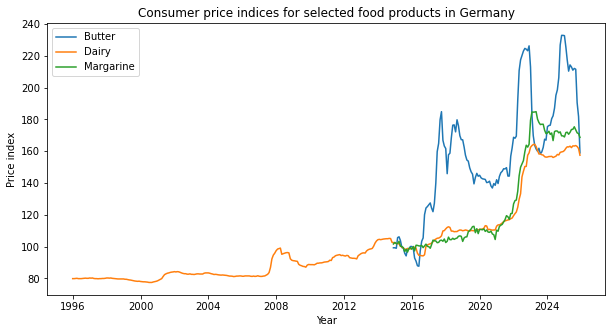

In [26]:
plt.figure(figsize=(10,5))

plt.plot(price_df["date"], price_df["butter_price"], label="Butter")
plt.plot(price_df["date"], price_df["dairy_price"], label="Dairy")
plt.plot(price_df["date"], price_df["margarine_price"], label="Margarine")

plt.legend()
plt.title("Consumer price indices for selected food products in Germany")
plt.xlabel("Year")
plt.ylabel("Price index")

plt.show()

### Interpretation

The figure illustrates the development of consumer price indices
for selected food products in Germany. All three product categories
show noticeable price increases over the observed period.

Particularly after 2021, prices rise more strongly, reflecting
the broader food inflation that occurred in Europe during this time.
These price increases can be interpreted as potential "price spikes"
that may influence public perception and economic concerns.

## 2. Price Development and Public Attention

Price increases may not only affect household budgets but also
attract public attention. One way to measure this attention is
through online search behavior.

Google Trends data provides an indicator of how frequently users
search for specific terms related to food prices. By comparing
search interest with price developments, it is possible to explore
whether rising prices are accompanied by increased public interest.

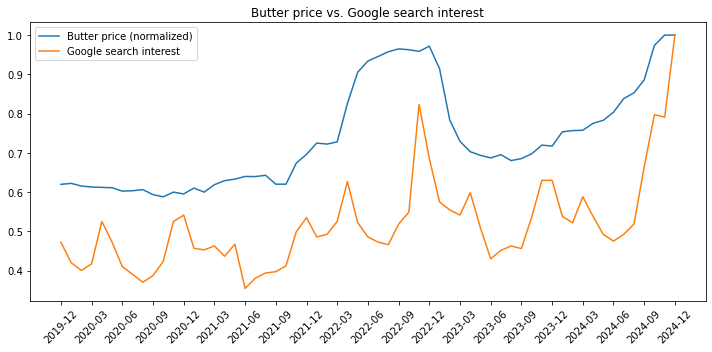

In [38]:
plt.figure(figsize=(10,5))

butter_norm = merged_df["butter_price"] / merged_df["butter_price"].max()
search_norm = merged_df["butter_search_interest"] / merged_df["butter_search_interest"].max()

x = merged_df["year_month"].astype(str)

plt.plot(x, butter_norm, label="Butter price (normalized)")
plt.plot(x, search_norm, label="Google search interest")

plt.xticks(ticks=range(0, len(x), 3), labels=x.iloc[::3], rotation=45)
plt.legend()
plt.title("Butter price vs. Google search interest")
plt.tight_layout()
plt.show()

### Interpretation

The figure compares the normalized development of butter prices
with Google search interest. Both series are scaled to allow
a visual comparison.

Periods of rising prices appear to coincide with increased search
activity, suggesting that consumers respond to higher food prices
by seeking more information. This pattern indicates that price
developments may influence public awareness and attention.

## 3. Most Frequent Economic Concern Terms in YouTube Comments

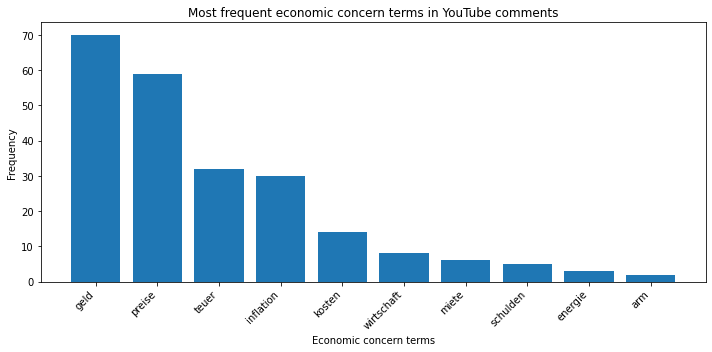

In [41]:
from collections import Counter

fear_word_counter = Counter()

for comment in comments_df["comment"].astype(str):
    tokens = tokenize_german_text(comment)
    for token in tokens:
        if token in FEAR_WORDS:
            fear_word_counter[token] += 1

top_fear_words = fear_word_counter.most_common(10)

words = [w for w, c in top_fear_words]
counts = [c for w, c in top_fear_words]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xlabel("Economic concern terms")
plt.ylabel("Frequency")
plt.title("Most frequent economic concern terms in YouTube comments")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretation
The chart shows that economic concern in YouTube comments is expressed above all through terms related to money, prices, and inflation. The most frequent terms are *geld*, *preise*, *teuer*, and *inflation*, which suggests that users often connect food prices with financial pressure and rising living costs.

Less frequent but still relevant terms such as *miete*, *schulden*, *energie*, and *arm* indicate that the discussion is not limited to butter prices alone, but is embedded in a broader perception of economic strain. Overall, the results suggest that online discourse about food prices contains clear references to affordability and economic stress.

### 4. Lagged Relationship Between Prices and Search Interest

To examine whether earlier price increases are reflected in later public attention, lagged correlations are calculated between butter prices and Google search interest. This helps evaluate whether price spikes are associated with increased search activity in the following months.

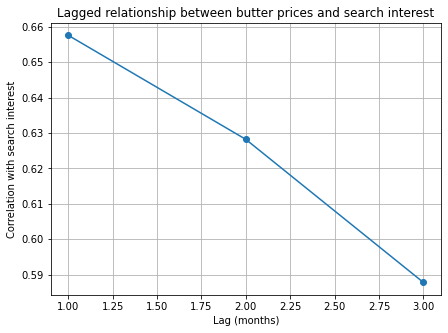

In [29]:
plt.figure(figsize=(7,5))

plt.plot(lag_df["lag_months"], lag_df["correlation"], marker="o")

plt.xlabel("Lag (months)")
plt.ylabel("Correlation with search interest")
plt.title("Lagged relationship between butter prices and search interest")

plt.grid(True)

plt.show()

### Interpretation

The lagged correlations help assess whether increases in butter prices are followed by higher public attention in subsequent months. 

If the correlations remain positive for one or more lag periods, this suggests that price increases may not only trigger immediate reactions but may also influence public attention over time. In other words, rising food prices may contribute to sustained public concern and discussion rather than only short-term interest.

However, these correlations should be interpreted cautiously. They indicate association rather than causation and do not prove that price increases directly cause changes in search behavior.

## 5. Economic Anxiety in Online Discussions

Beyond search behavior, public discourse about food prices can
also be observed in online discussions. YouTube comments related
to food inflation in Germany provide qualitative insights into
how people perceive rising prices.

To quantify economic concern, a simple "fear score" is calculated
based on the presence of keywords related to economic anxiety
such as *expensive*, *inflation*, *crisis*, or *affordability*.

In [30]:
comments_df["fear_score"] = comments_df["comment"].apply(fear_score)
comments_df["fear_present"] = comments_df["fear_score"] > 0

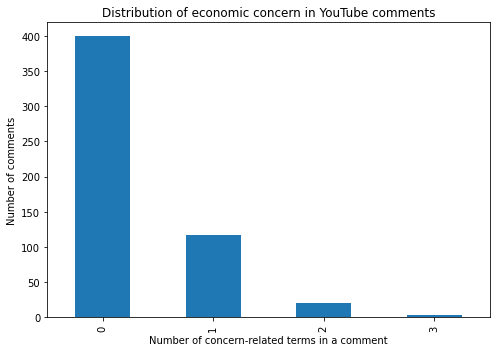

In [39]:
plt.figure(figsize=(7,5))

comments_df["fear_score"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Number of concern-related terms in a comment")
plt.ylabel("Number of comments")
plt.title("Distribution of economic concern in YouTube comments")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of fear scores indicates that a considerable
share of comments contains language associated with economic
concerns. Many users refer to rising prices, financial pressure,
or the affordability of food.

These findings suggest that discussions about food prices are
often framed in terms of economic insecurity and household
financial stress.

## 5. Conclusion

This study examined whether rising butter prices in Germany are associated with increased public attention and signs of economic concern.

The results indicate a positive relationship between butter prices and Google search interest, particularly when considering short time lags. This suggests that rising butter prices are associated with increased public attention, especially when short time lags are considered.

The analysis of YouTube comments further shows that a notable share of discussions includes terms related to financial stress, rising costs, and economic pressure. Frequently mentioned terms such as "teuer", "Inflation", and "Kosten" indicate that butter price increases are embedded in a broader perception of economic strain.

However, the analysis is limited by its reliance on correlation and keyword-based measures of concern. Therefore, the results should be interpreted as evidence of an association rather than proof of a causal relationship between butter prices and economic anxiety.